In [11]:
#Célula de prepação e carregamento dos dados(igual ao que joão já havia feito anteriormente)

import pandas as pd

#leitura do parquet
df = pd.read_parquet('../../dataset/data.parquet', engine='fastparquet')

#removendo clientes que não possuem meta de poupança
df = df[df['Desired_Savings'] > 0]


df['perc_nao_essenciais'] = (df['Eating_Out'] + df['Entertainment']) / df['Income']

#criando nova coluna em relação ao percentual do empréstimo
df['perc_emprestimo'] = df['Loan_Repayment'] / df['Income']


#colunas de potencial
colunas_potencial = [
    'Potential_Savings_Groceries',
    'Potential_Savings_Transport',
    'Potential_Savings_Eating_Out',
    'Potential_Savings_Entertainment',
    'Potential_Savings_Utilities',
    'Potential_Savings_Healthcare',
    'Potential_Savings_Education',
    'Potential_Savings_Miscellaneous'
]

df['total_potential_savings'] = df[colunas_potencial].sum(axis=1)
#soma de todos os gastos potenciais/renda
df['perc_potential_savings'] = df['total_potential_savings'] / df['Income']

df['total_potential_savings'] = df[colunas_potencial].sum(axis=1)

#percentual de quanto sobra pra emergencia
df['buffer_emergencia'] = (df['Disposable_Income'] - df['Desired_Savings']) / df['Income']

#criando o valor de risco de score de crédito
#empréstimo comendo mais que 10% da renda
c1 = (df['perc_emprestimo'] > 0.10).astype(int)
#compra não essenciais altas
c2 = (df['perc_nao_essenciais'] > 0.085).astype(int)
#buffer de emergencia menor que 10% da renda
c3 = (df['buffer_emergencia'] < 0.10).astype(int)
#percentual de potenciais salvamentos maior que 0.08
c4 = (df['perc_potential_savings'] > 0.08).astype(int)

df['risk_score'] = c1 + c2 + c3 + c4


# Definição do target para identificar a partir de quantas condições
# o usuário será definido como vulnerável
#se o score de risco for maior ou igual a 2 então coloca que é vulnerável
#gabarito oficial
df['Vulnerable'] = (df['risk_score'] >= 2).astype(int)
df['Vulnerable'].value_counts()




Vulnerable
0    15357
1     4531
Name: count, dtype: int64

In [12]:
# Bloco 14 -- Comparando os grupos de vulneravel e não vuleravel

df.groupby('Vulnerable')[['Income', 'perc_emprestimo', 'perc_nao_essenciais', 'buffer_emergencia', 'perc_potential_savings']].mean().round(4)

,Income,perc_emprestimo,perc_nao_essenciais,buffer_emergencia,perc_potential_savings
Vulnerable,,,,,
0,39739.8395,0.0246,0.0688,0.1953,0.0610
1,47741.3189,0.1322,0.0739,0.0490,0.0655


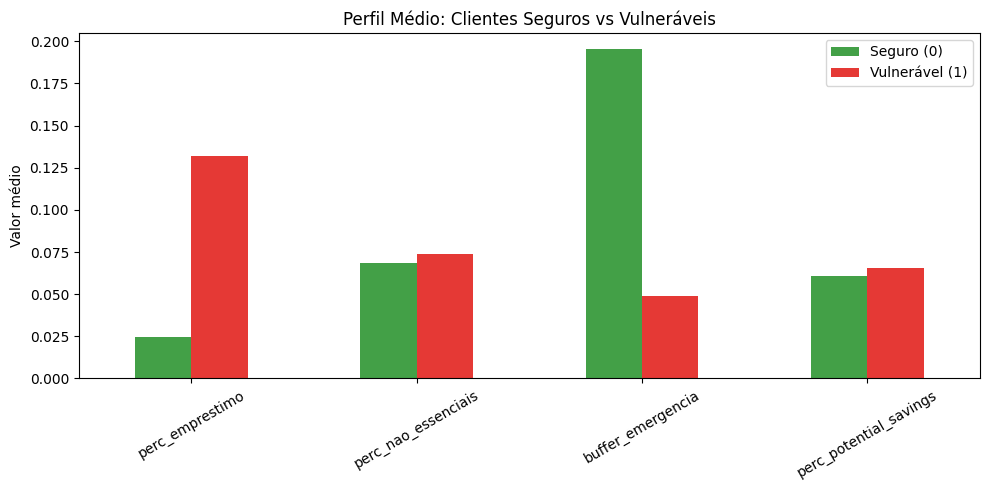

In [13]:
import matplotlib.pyplot as plt

grupos = df.groupby('Vulnerable')[['perc_emprestimo', 'perc_nao_essenciais', 'buffer_emergencia', 'perc_potential_savings']].mean()

#plotando o valor médio em relação ao grupo
#pessoas seguras tem buffer grande
grupos.T.plot(kind='bar', figsize=(10, 5), color=['#43a047', '#e53935'])
plt.title('Perfil Médio: Clientes Seguros vs Vulneráveis')
plt.ylabel('Valor médio')
plt.xticks(rotation=30)
plt.legend(['Seguro (0)', 'Vulnerável (1)'])
plt.tight_layout()

plt.show()

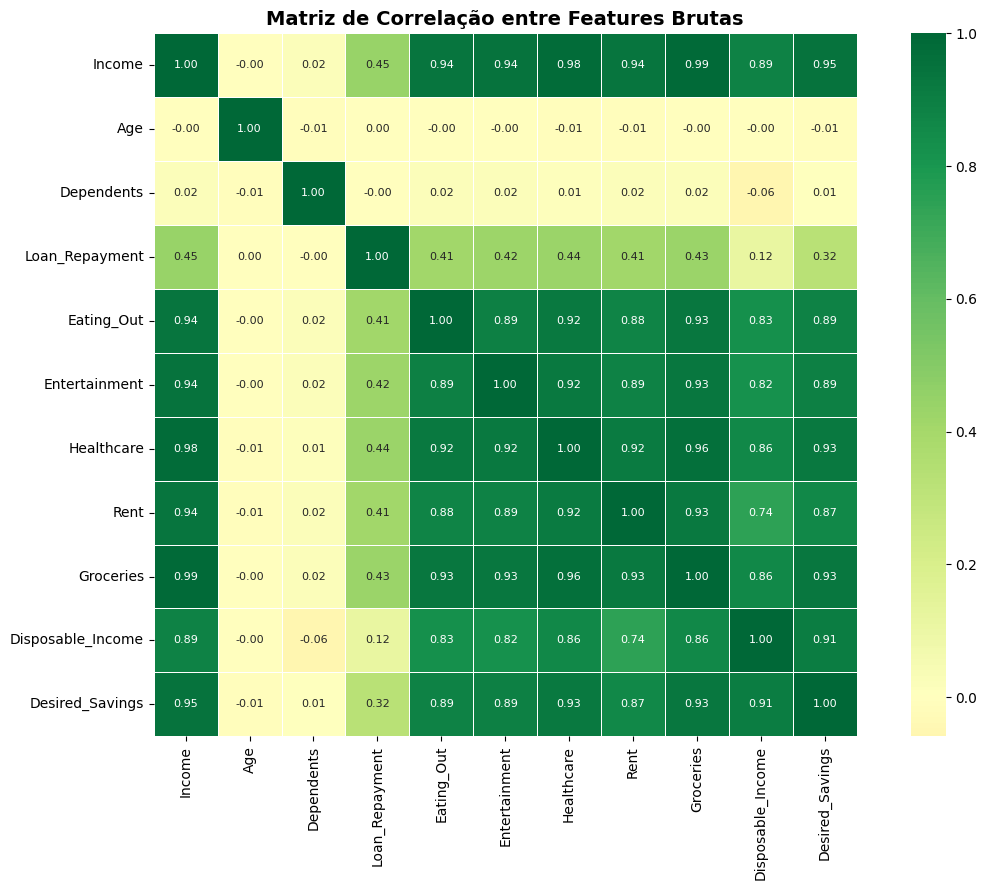


 ALERTA DE MULTICOLINEARIDADE (> 0.7 ou < -0.7) 
Estes são os ruídos que nossos modelos (KNN e XGBoost) terão que enfrentar:
  Eating_Out ↔ Income: 0.94
  Entertainment ↔ Income: 0.94
  Healthcare ↔ Income: 0.98
  Rent ↔ Income: 0.94
  Groceries ↔ Income: 0.99
  Disposable_Income ↔ Income: 0.89
  Desired_Savings ↔ Income: 0.95
  Entertainment ↔ Eating_Out: 0.89
  Healthcare ↔ Eating_Out: 0.92
  Rent ↔ Eating_Out: 0.88
  Groceries ↔ Eating_Out: 0.93
  Disposable_Income ↔ Eating_Out: 0.83
  Desired_Savings ↔ Eating_Out: 0.89
  Healthcare ↔ Entertainment: 0.92
  Rent ↔ Entertainment: 0.89
  Groceries ↔ Entertainment: 0.93
  Disposable_Income ↔ Entertainment: 0.82
  Desired_Savings ↔ Entertainment: 0.89
  Rent ↔ Healthcare: 0.92
  Groceries ↔ Healthcare: 0.96
  Disposable_Income ↔ Healthcare: 0.86
  Desired_Savings ↔ Healthcare: 0.93
  Groceries ↔ Rent: 0.93
  Disposable_Income ↔ Rent: 0.74
  Desired_Savings ↔ Rent: 0.87
  Disposable_Income ↔ Groceries: 0.86
  Desired_Savings ↔ Groceries:

In [14]:
# Bloco 16 e 17 Refatorados -- Análise de Correlação com as Variáveis Reais (Sem Leakage)

import matplotlib.pyplot as plt
import seaborn as sns

# As variáveis brutas definitivas que o seu amigo selecionou
features_verdadeiras = [
    'Income', 'Age', 'Dependents', 'Loan_Repayment',
    'Eating_Out', 'Entertainment', 'Healthcare',
    'Rent', 'Groceries', 'Disposable_Income', 'Desired_Savings'
]

# Separando X (Features) e y (Target)
X = df[features_verdadeiras]
y = df['Vulnerable']

# Matriz de correlação entre as features definitivas
corr_matrix = X.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title('Matriz de Correlação entre Features Brutas', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

print("\n ALERTA DE MULTICOLINEARIDADE (> 0.7 ou < -0.7) ")
print("Estes são os ruídos que nossos modelos (KNN e XGBoost) terão que enfrentar:")
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and abs(corr_matrix.loc[row, col]) > 0.7:
            # Imprime apenas uma vez cada par para não duplicar no console
            if list(corr_matrix.columns).index(row) > list(corr_matrix.columns).index(col):
                print(f"  {row} ↔ {col}: {corr_matrix.loc[row, col]:.2f}")

In [15]:
# Bloco 18 -- Redução da dimensionalidade, alterações das features
#feature foram reduzidas para que não tivesse data leakage
features_reduzidas = [
    'Income', 'Age', 'Dependents', 'Loan_Repayment',
              'Eating_Out', 'Entertainment', 'Healthcare',
              'Rent', 'Groceries', 'Disposable_Income', 'Desired_Savings'
]

#conteúdo da prova
X = df[features_reduzidas]
#gabarito da prova
y = df['Vulnerable']

#features que serão usadas
print(f"\nFeatures mantidas: {features_reduzidas}")


Features mantidas: ['Income', 'Age', 'Dependents', 'Loan_Repayment', 'Eating_Out', 'Entertainment', 'Healthcare', 'Rent', 'Groceries', 'Disposable_Income', 'Desired_Savings']


In [16]:
# Bloco 19 -- Divisão treino e teste
# Evitar overfitting (decorar dados e replicar, não aprender)
# Separação dos dados em dois grupos: 80% treino e 20% teste

from sklearn.model_selection import train_test_split

#20% da base para o teste final
#tratify força a estatística: se a base original tem 20% de pessoas 
# vulneráveis no total, o Caderno de Estudos e a Prova Final terão exatamente 20% de vulneráveis cada.
#random_state =número garante que o embaralhamento será exatamente o mesmo toda vez que você rodar o código.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino:  {X_train.shape[0]} clientes")
print(f"Teste:   {X_test.shape[0]} clientes")


#normalizando os dados para que valores maiores não pesem mais que valores menores

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
#separando a função que será para treino
X_train_scaled = scaler.fit_transform(X_train)
#separando a porção que será para teste
X_test_scaled = scaler.transform(X_test)

print("Normalização concluída!")

Treino:  15910 clientes
Teste:   3978 clientes
Normalização concluída!


In [26]:
# Bloco 21 -- A Nova Arquitetura de Modelos (KNN e XGBoost)

from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


#veremos quais são os vizinhos mais próximos de tal usuário
knn = KNeighborsClassifier(n_neighbors=5)


#scale_pos_weight=4 avisa que a classe minoritária (vulnerável(a partir do dado mostrado mais pra cima)) é 4x mais importante.
#
xgb = XGBClassifier(
    random_state=42, 
    scale_pos_weight=4, 
    eval_metric='logloss'
)

print("Iniciando o treinamento dos modelos na base padronizada...")

#treinando o algoritmo knn com os dados de treino
knn.fit(X_train_scaled, y_train)
print("KNN treinado")

#treinando o algoritmo xgb com osd ados de treino
xgb.fit(X_train_scaled, y_train)
print("XGBoost treinado")

Iniciando o treinamento dos modelos na base padronizada...
KNN treinado
XGBoost treinado



 KNN — AUC-ROC Global: 0.9277
              precision    recall  f1-score   support

      Seguro       0.92      0.96      0.94      3072
  Vulnerável       0.84      0.74      0.78       906

    accuracy                           0.91      3978
   macro avg       0.88      0.85      0.86      3978
weighted avg       0.90      0.91      0.90      3978



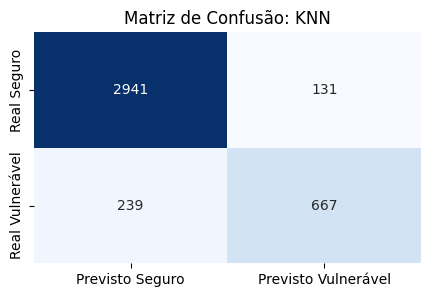


 XGBoost — AUC-ROC Global: 0.9759
              precision    recall  f1-score   support

      Seguro       0.96      0.95      0.96      3072
  Vulnerável       0.84      0.87      0.85       906

    accuracy                           0.93      3978
   macro avg       0.90      0.91      0.90      3978
weighted avg       0.93      0.93      0.93      3978



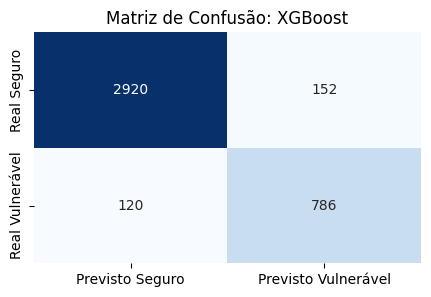

In [27]:
# Bloco 22 -- Avaliação da Nossa Arquitetura (KNN vs XGBoost)

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Trocamos os modelos do seu amigo pelos nossos
modelos_nossos = {
    'KNN': knn,
    'XGBoost': xgb
}

resultados_nossos = {}

for nome, modelo in modelos_nossos.items():

    #fazendo a prova final(previsão)
    y_pred = modelo.predict(X_test_scaled)
    
    #probabilidade de ser classe 1 ou classe 0,por exemplo
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    
    # A nota geral de separação
    auc = roc_auc_score(y_test, y_prob)
    resultados_nossos[nome] = {'auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}
    
    # Imprimindo o Boletim de Notas
    print(f"\n{'='*60}")
    print(f" {nome} — AUC-ROC Global: {auc:.4f}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['Seguro', 'Vulnerável']))
    
    # O Raio-X Visual (Matriz de Confusão)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Previsto Seguro', 'Previsto Vulnerável'],
                yticklabels=['Real Seguro', 'Real Vulnerável'])
    plt.title(f'Matriz de Confusão: {nome}')
    plt.show()

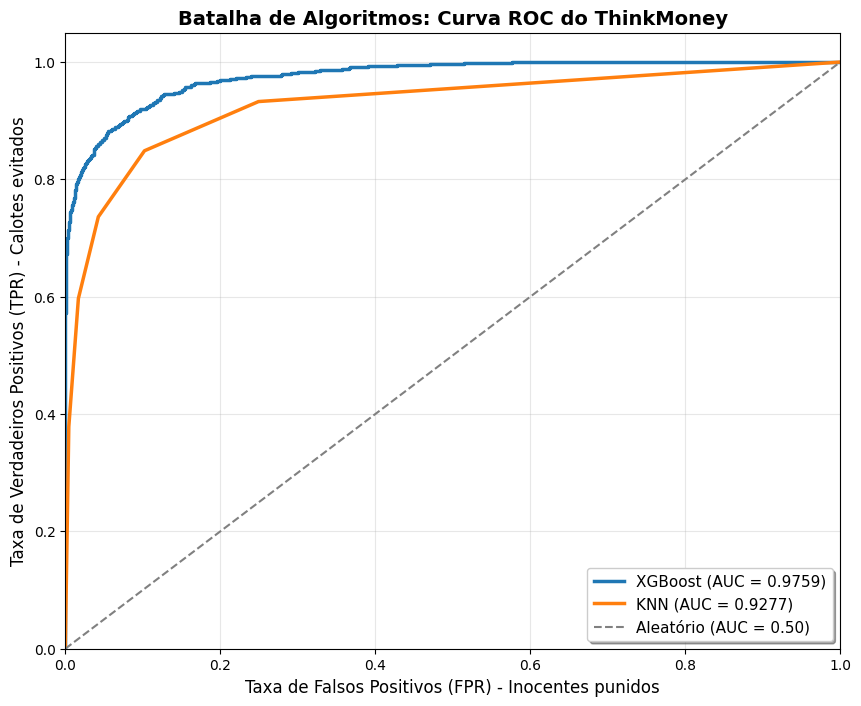

✅ Gráfico ROC comparativo gerado e salvo com sucesso!


In [9]:
#Plotagem da Curva ROC Comparativa

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

#Dicionário com os modelos já treinados (usaremos a base de TESTE para evitar viés)
modelos_plot = {
    'XGBoost': xgb,
    'KNN': knn
}

#Criando a tela do gráfico com tamanho ampliado
plt.figure(figsize=(10, 8))

#Loop para calcular e desenhar a curva de cada modelo automaticamente
for nome, modelo in modelos_plot.items():
    
    #1.Calcula a probabilidade de ser vulnerável
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    
    #2.Gera os pontos da curva ROC(Falso Positivo vs Verdadeiro Positivo)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    #3.Calcula a nota final de área(AUC)
    area = auc(fpr, tpr)
    
    #4.Desenha a linha do modelo na tela
    plt.plot(fpr, tpr, linewidth=2.5, label=f'{nome} (AUC = {area:.4f})')

#Desenhando a linha diagonal de referência (o modelo "jogar moeda para cima")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Aleatório (AUC = 0.50)')

#Estética,limites e legendas do gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR) - Inocentes punidos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Calotes evitados', fontsize=12)
plt.title('Batalha de Algoritmos: Curva ROC do ThinkMoney', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3)

#Salvando a imagem no computador e exibindo na tela
plt.savefig('curva_roc_thinkmoney.png', dpi=300, bbox_inches='tight')
plt.show()

#Aviso de conclusão
print("✅ Gráfico ROC comparativo gerado e salvo com sucesso!")

c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calculando oráculo do XGBoost (TreeExplainer)...


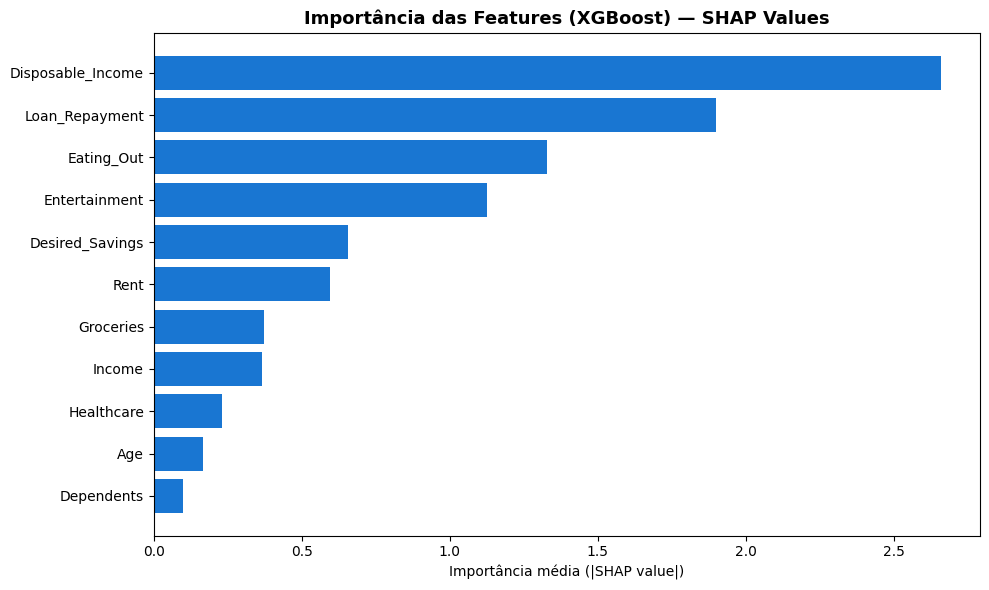

✅ SHAP do XGBoost gerado com sucesso!

AVISO DE PERFORMANCE: Iniciando o oráculo do KNN (KernelExplainer)...
Isto pode levar vários minutos, por favor, aguarde o Python calcular as distâncias multidimensionais.


100%|██████████| 50/50 [01:02<00:00,  1.24s/it]


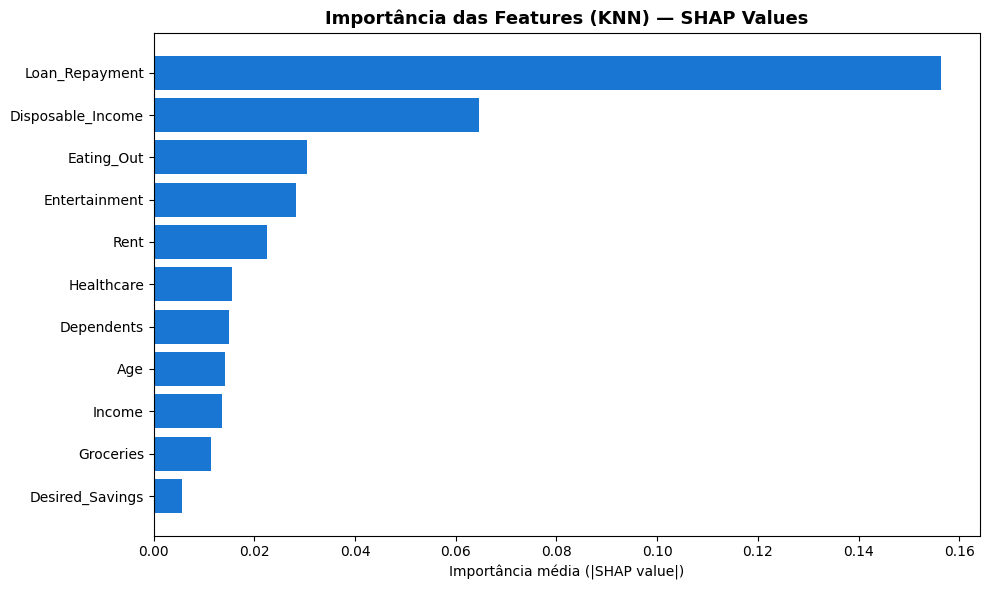

✅ SHAP do KNN gerado com sucesso.

Análise de transparência concluída.


In [ ]:


import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



features_verdadeiras = [
    'Income', 'Age', 'Dependents', 'Loan_Repayment',
    'Eating_Out', 'Entertainment', 'Healthcare',
    'Rent', 'Groceries', 'Disposable_Income', 'Desired_Savings'
]

def plot_shap_importance(explainer, shap_values, model_name, features_list,filename ,is_knn=False):
    """
    Função para processar a estrutura complexa do SHAP e gerar o gráfico
    de importância média para classificação binária da classe 1.
    """
    #explainer=motor do shap usado

    #matriz do impacto das variáveis para cada cliente
    sv = shap_values
    
    # SHAP output varia entre classificadores: extraímos a Classe 1 (Vulnerável)
    # Se for uma lista (ex: XGBoost log-odds), pegamos o segundo elemento.
    if isinstance(sv, list):
        sv = sv[1]
    # Se for um array de KernelExplainer com classes extras
    elif len(sv.shape) == 3 and is_knn:
         sv = sv[:, :, 1] # Pega samples x features da classe 1
    
    #Calcular importância média (SHAP)
    mean_shap = np.abs(sv).mean(axis=0)
    
    #Criar DataFrame e ordenar
    shap_df = pd.DataFrame({
        'feature': features_list,
        'importancia': mean_shap
    }).sort_values('importancia', ascending=True)

   
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(shap_df['feature'], shap_df['importancia'], color='#1976d2')
    ax.set_title(f'Importância das Features ({model_name}) — SHAP Values', fontweight='bold', fontsize=13)
    ax.set_xlabel('Importância média (|SHAP value|)')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

#shap xgboost
print("Calculando oráculo do XGBoost (TreeExplainer)...")

explainer_xgb = shap.TreeExplainer(xgb)

shap_values_xgb = explainer_xgb.shap_values(X_test_scaled)


plot_shap_importance(explainer_xgb, shap_values_xgb, "XGBoost", features_verdadeiras,"grafico_shap_XGBoost")
print(" SHAP do XGBoost gerado com sucesso!")


#shap do KNN É MUITO LENTO(DEMOROU 1H e 22 min na minha máuina)
print("\nAVISO DE PERFORMANCE: Iniciando o oráculo do KNN (KernelExplainer)...")
print("Isto pode levar vários minutos, por favor, aguarde o Python calcular as distâncias multidimensionais.")

#Como o KernelExplainer faz força bruta, nós não podemos deixá-lo testar combinações contra as 16.000 linhas de treino 
# originais. O algoritmo K-means comprime toda a sua base de treino em apenas 10 avatares sintéticos (centróides) 
# que representam as médias dos usuários. Isso reduz o tempo de processamento de semanas para minutos.
background_data = shap.kmeans(X_train_scaled, 10) 

# KernelExplainer usa a função predict_proba do modelo
explainer_knn = shap.KernelExplainer(knn.predict_proba, background_data)


shap_values_knn = explainer_knn.shap_values(X_test_scaled[:50])

# Processa e Plota (KernelExplainer geralmente retorna [samples x features x classes])
plot_shap_importance(explainer_knn, shap_values_knn, "KNN", features_verdadeiras,"grafico_shap_KNN" ,is_knn=True,)
print(" SHAP do KNN gerado com sucesso.")

print("\nAnálise de transparência concluída.")

Gerando Pareto para o XGBoost...


C:\Users\mathe\AppData\Local\Temp\ipykernel_54096\1911521375.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(shap_df['feature'], rotation=30, ha='right')


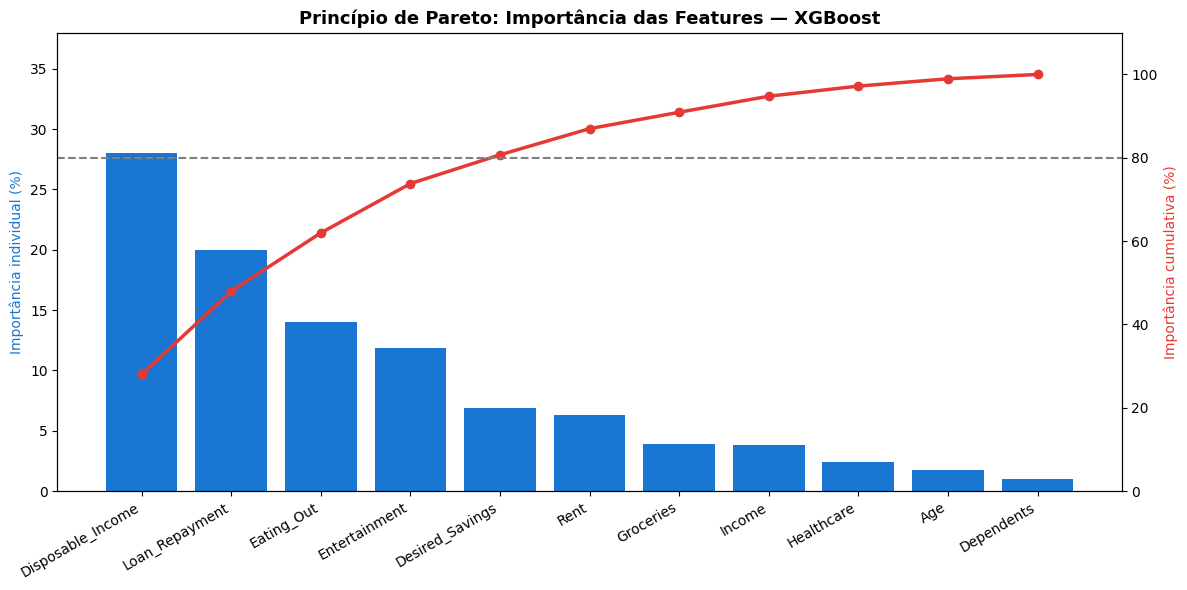

✅ Gráfico de Pareto para XGBoost salvo como 'pareto_xgboost.png'!

Gerando Pareto para o KNN...


C:\Users\mathe\AppData\Local\Temp\ipykernel_54096\1911521375.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(shap_df['feature'], rotation=30, ha='right')


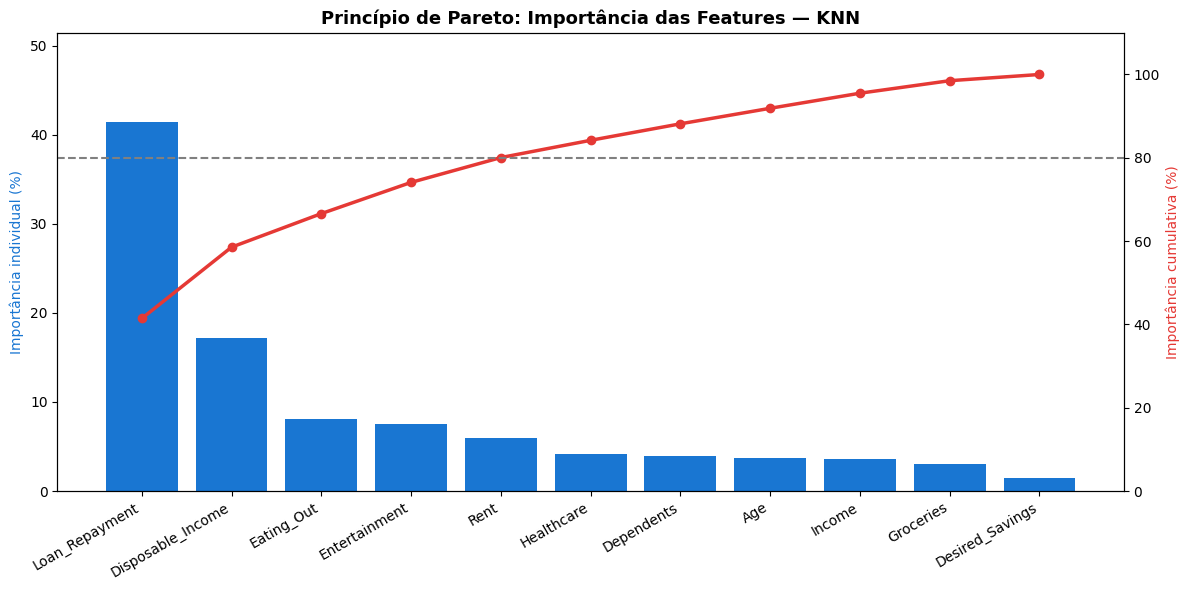

✅ Gráfico de Pareto para KNN salvo como 'pareto_knn.png'!


In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


features_verdadeiras = [
    'Income', 'Age', 'Dependents', 'Loan_Repayment',
    'Eating_Out', 'Entertainment', 'Healthcare',
    'Rent', 'Groceries', 'Disposable_Income', 'Desired_Savings'
]

def plot_pareto_shap(shap_values, model_name, features_list, filename, is_knn=False):
    """
    Calcula o impacto percentual das features e plota o Gráfico de Pareto.
    """
    sv = shap_values
    
    #mesmo tratamento na célula passada
    if isinstance(sv, list):
        sv = sv[1]
    elif len(sv.shape) == 3 and is_knn:
        sv = sv[:, :, 1]
        
    # 2. Calcula a importância bruta
    mean_shap = np.abs(sv).mean(axis=0)
    
    # Cria o DataFrame e ORDENA DO MAIOR PARA O MENOR (Essencial para Pareto)
    shap_df = pd.DataFrame({
        'feature': features_list,
        'importancia': mean_shap
    }).sort_values('importancia', ascending=False)
    
    # Matemática do Pareto Porcentagem Individual e Acumulada)
    shap_df['importancia_pct'] = (shap_df['importancia'] / shap_df['importancia'].sum()) * 100
    shap_df['cumulativo'] = shap_df['importancia_pct'].cumsum()
    
    
    fig, ax1 = plt.subplots(figsize=(12, 6))

    #Eixo Y Esquerdo (Barras Azuis - Impacto Individual)
    ax1.bar(shap_df['feature'], shap_df['importancia_pct'], color='#1976d2', label='Importância %')
    ax1.set_ylabel('Importância individual (%)', color='#1976d2')
    ax1.set_xticklabels(shap_df['feature'], rotation=30, ha='right')
    ax1.set_ylim(0, max(shap_df['importancia_pct']) + 10) 

    #Eixo Y Direito (Linha Vermelha - Acumulado)
    ax2 = ax1.twinx()
    ax2.plot(shap_df['feature'], shap_df['cumulativo'], color='#e53935',
             marker='o', linewidth=2.5, label='Cumulativo %')
    
    # Onde corta 80%
    ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1.5, label='Corte de 80%')
    ax2.set_ylabel('Importância cumulativa (%)', color='#e53935')
    ax2.set_ylim(0, 110)

    plt.title(f'Princípio de Pareto: Importância das Features — {model_name}', fontsize=13, fontweight='bold')
    fig.tight_layout()
    
    
    plt.savefig(filename, dpi=300)
    plt.show()
    print(f" Gráfico de Pareto para {model_name} salvo como '{filename}'!")



print("Gerando Pareto para o XGBoost...")
plot_pareto_shap(shap_values_xgb, "XGBoost", features_verdadeiras, "pareto_xgboost.png")

print("\nGerando Pareto para o KNN...")

plot_pareto_shap(shap_values_knn, "KNN", features_verdadeiras, "pareto_knn.png", is_knn=True)

In [ ]:
#Comparativo KNN vs XGBoost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#lista de colunas usadas
features_b = ['Income', 'Age', 'Dependents', 'Loan_Repayment',
              'Eating_Out', 'Entertainment', 'Healthcare',
              'Rent', 'Groceries', 'Disposable_Income', 'Desired_Savings']

#Extraindo os dados brutos da base original
X_completo = df[features_b]

#Aplicando a mesma régua de padronização que usamos no treino
X_completo_scaled = scaler.transform(X_completo)

modelos_finais = {
    'KNN': knn,
    'XGBoost': xgb
}

#Função com a regra de negócios 
def classificar_risco(prob):
    #Se o risco for menor que 30%, aprova sem dor de cabeça
    if prob < 0.30:
        return 'Baixo'
    #Se o risco for até 60%, entra na zona de alerta para renegociação leve
    elif prob < 0.60:
        return 'Médio'
    #Se passar de 60%, a bomba vai explodir, acionar cobrança imediatamente
    else:
        return 'Alto'

#Abertura do arquivo de texto para escrita ('w' de write) com suporte a acentuação
with open('relatorio_modelos_financeiros.txt', 'w', encoding='utf-8') as f:

    #Iniciando o loop que vai gerar o relatório para cada um dos dois algoritmos
    for nome, modelo in modelos_finais.items():
        
        print(f"\n{'='*70}", file=f)
        print(f"  RELATÓRIO FINANCEIRO E DE RISCO — MODELO: {nome.upper()}", file=f)
        print(f"{'='*70}", file=f)
        
        #O predict_proba devolve a % de certeza. O [:, 1] puxa só a chance de ser Vulnerável

        #modelo.predict(X_test_scaled) é binário,retornando apenas 0 e 1,ele decide automaticamente por vc
        #já o modelo.preditc_proba retorna um array das probabilidades tendo como primeiro valor se ser
        #seguro e segubdo valor de ser vulnerável
        #essa linha de código irá criar uma nova coluna chamada probabilidaed_risco
        df['probabilidade_risco'] = modelo.predict_proba(X_completo_scaled)[:, 1]
        
        #a partir da nova coluna criada,irá definir qual tipo de cliente
        df['nivel_risco'] = df['probabilidade_risco'].apply(classificar_risco)
        
        #Agrupando a base pela tipo de nível de risco(baixo,médio ou alto)
        #cria um novo dataset com esses valores,ficando masi ou menos nesse formato

        """
        [
      { "nivel_risco": "Baixo", "clientes": 12500, "renda_media": 8500, "emprestimo_medio": 1200 },
      { "nivel_risco": "Médio", "clientes": 4500,  "renda_media": 4200, "emprestimo_medio": 3500 },
      { "nivel_risco": "Alto",  "clientes": 3000,  "renda_media": 2100, "emprestimo_medio": 6000 }
    ]
        """
        segmentacao = df.groupby('nivel_risco').agg(
            #sintaxe agg(nome da coluna,conta_matemática)

            #Contando quantas linhas (clientes) caíram 
            clientes=('Income', 'count'),

            #Tirando a média da renda da galera 
            renda_media=('Income', 'mean'),

            #Tirando a média do valor do empréstimo 
            emprestimo_medio=('Loan_Repayment', 'mean'),

            #A média do score de risco matemático
            prob_media=('probabilidade_risco', 'mean')
        ).reindex(['Baixo', 'Médio', 'Alto']) #reogarniza a tabela
        
        #Calculando qual porcentagem da base total de clientes cada nível  representa
        segmentacao['pct_base'] = (segmentacao['clientes'] / len(df) * 100).round(1)
        
        #tamanho do rombo caso aquele tipo pessoa deixasse de pagar
        segmentacao['exposicao_mensal'] = segmentacao['clientes'] * segmentacao['emprestimo_medio']
        
        print(" SEGMENTAÇÃO DE CLIENTES POR NÍVEL DE RISCO", file=f)
        print("-" * 70, file=f)
        
        for nivel in ['Baixo', 'Médio', 'Alto']:
            
            if nivel in segmentacao.index and not pd.isna(segmentacao.loc[nivel, 'clientes']):
                row = segmentacao.loc[nivel]
                print(f"\n🔹 Risco {nivel}:", file=f)
                print(f"   Clientes:            {int(row['clientes']):,}", file=f)
                print(f"   % da base:           {row['pct_base']}%", file=f)
                print(f"   Prob. média:         {row['prob_media']*100:.1f}%", file=f)
                print(f"   Empréstimo médio:    R$ {row['emprestimo_medio']:,.0f}", file=f)
                print(f"   Exposição mensal:    R$ {row['exposicao_mensal']:,.0f}", file=f)
                
        #Isolando especificamente a gaveta de ALTO RISCO para calcularmos o ROI do projeto
        if 'Alto' in segmentacao.index and not pd.isna(segmentacao.loc['Alto', 'clientes']):
            alto_risco = segmentacao.loc['Alto']
            exposicao_total = alto_risco['exposicao_mensal']
            
            #A premissa da diretoria: Agindo preventivamente salvamos 30% desse dinheiro
            economia_30pct = exposicao_total * 0.30
            
            print("\n" + "-" * 70, file=f)
            print(" IMPACTO FINANCEIRO — GRUPO DE ALTO RISCO", file=f)
            print("-" * 70, file=f)
            print(f"\n   Clientes prestes a quebrar:  {int(alto_risco['clientes']):,}", file=f)
            print(f"   Dinheiro total em risco:     R$ {exposicao_total:,.0f}", file=f)
            print(f"   Lucro salvo pelo {nome}:     R$ {economia_30pct:,.0f}", file=f)
            print(f"\n   * Valor baseado na prevenção de 30% das inadimplências", file=f)
            print(f"     através da inteligência preditiva do {nome}.", file=f)

#Aviso na tela de que o arquivo foi gerado
print(" Relatório gerado com sucesso no arquivo 'relatorio_modelos_financeiros.txt'!")

✅ Relatório gerado com sucesso no arquivo 'relatorio_modelos_financeiros.txt'!
